# 04 — Fine Wine Heterogeneity Analysis

**Purpose**: Demonstrate that fine wine is highly heterogeneous — individual wines behave very
differently from each other and from market indices during downturns.

**Target wines** (LWIN7): Salon (1807626), Dom Pérignon (1082656), Lafite (1011872)

**Data source**: `focal_wines_vwap_monthly.parquet` produced by `01_data_setup.ipynb`

## Sections
1. Environment setup
2. Load parquets & prepare series
3. Chart 1: VWAP price series (2005+)
4. Chart 2: GFC drawdown comparison (indexed to 100 at Jan 2007)
5. Chart 3: Monthly trade volume per wine
6. Chart 4: Stress period performance — grouped bar
7. Data quality assertions

## 1. Environment Setup

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import yfinance as yf
from pathlib import Path

warnings.filterwarnings("ignore")

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white'})

# ---------------------------------------------------------------------------
# Paths — notebook lives in projects/correlation-diversification/notebooks/
# ---------------------------------------------------------------------------
NOTEBOOK_DIR = Path("__file__").resolve().parent
PROJECT_DIR  = NOTEBOOK_DIR.parent
DATA_DIR     = PROJECT_DIR / "data"
IMAGES_DIR   = PROJECT_DIR / "images" / "heterogeneity"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

FOCAL_WINES_PARQUET = DATA_DIR / "focal_wines_vwap_monthly.parquet"
COMPARISON_PARQUET  = DATA_DIR / "comparison_assets_monthly.parquet"

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------
WINE_LABELS = {
    "1807626": "Salon",
    "1082656": "Dom Pérignon",
    "1011872": "Lafite",
}

# WineFi brand colours
WINEFI_COLOURS = [
    '#9437ff',  # purple  — primary
    '#83D483',  # mantis
    '#FFD166',  # sunglow
    '#F78C6B',  # coral
    '#4D87D0',  # blue
    '#EF476F',  # red
    '#06D6A0',  # emerald
    '#C23FB7',  # pink/purple
    '#4A4A68',  # slate
]

WINE_COLORS = {
    "Salon":        WINEFI_COLOURS[0],  # purple
    "Dom Pérignon": WINEFI_COLOURS[4],  # blue
    "Lafite":       WINEFI_COLOURS[5],  # red
}
LIVEX_COLOR  = WINEFI_COLOURS[1]  # mantis
SP500_COLOR  = WINEFI_COLOURS[2]  # sunglow
STRESS_SHADE = WINEFI_COLOURS[8]  # slate

# Stress periods as per issue spec
STRESS_PERIODS = [
    ("2008-09-01", "2009-03-31", "GFC"),
    ("2020-02-01", "2020-04-30", "COVID"),
    ("2022-01-01", "2022-12-31", "Rate rises"),
]

SPARSE_THRESHOLD = 5

print("Data dir:   ", DATA_DIR)
print("Images dir: ", IMAGES_DIR)
print("Focal wines parquet exists:", FOCAL_WINES_PARQUET.exists())
print("Comparison parquet exists: ", COMPARISON_PARQUET.exists())

Data dir:    /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/data
Images dir:  /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/heterogeneity
Focal wines parquet exists: True
Comparison parquet exists:  True


## 2. Load Parquets & Prepare Series

In [2]:
# ---------------------------------------------------------------------------
# Load focal wines
# ---------------------------------------------------------------------------
focal_raw = pd.read_parquet(FOCAL_WINES_PARQUET)
focal_raw["month"] = pd.to_datetime(focal_raw["month"])

# Normalise lwin7 to string for label lookup
focal_raw["lwin7"] = focal_raw["lwin7"].astype(str).str.strip()

# Apply label mapping (handles both 'Dom Perignon' and 'Dom Pérignon' in source)
focal_raw["wine_name"] = focal_raw["lwin7"].map(WINE_LABELS)

print(f"focal_wines_vwap_monthly: {focal_raw.shape}")
print(f"Date range: {focal_raw['month'].min().date()} → {focal_raw['month'].max().date()}")
print(f"Columns: {list(focal_raw.columns)}")
print()
print("LWIN7 → wine_name mapping:")
print(focal_raw[["lwin7", "wine_name"]].drop_duplicates().to_string(index=False))
print()
focal_raw.head(6)

focal_wines_vwap_monthly: (689, 6)
Date range: 2000-01-31 → 2025-12-31
Columns: ['month', 'lwin7', 'vwap_gbp', 'total_qty', 'trade_count', 'wine_name']

LWIN7 → wine_name mapping:
  lwin7    wine_name
1807626        Salon
1082656 Dom Pérignon
1011872       Lafite



,month,lwin7,vwap_gbp,total_qty,trade_count,wine_name
0,2000-01-31,1807626,117.84,41.3,6,Salon
1,2000-02-29,1807626,126.18,179.0,9,Salon
2,2000-03-31,1807626,123.25,99.2,11,Salon
3,2000-04-30,1807626,116.64,78.4,14,Salon
4,2000-05-31,1807626,119.30,17.5,2,Salon
5,2000-06-30,1807626,117.43,74.2,8,Salon


In [3]:
# ---------------------------------------------------------------------------
# Pivot to wide format: rows=month, cols=wine_name
# ---------------------------------------------------------------------------
wine_price_raw = focal_raw.pivot_table(
    index="month", columns="wine_name", values="vwap_gbp", aggfunc="first"
)
wine_price_raw.columns.name = None
wine_price_raw.index.name   = "date"

wine_trades_wide = focal_raw.pivot_table(
    index="month", columns="wine_name", values="trade_count", aggfunc="first"
)
wine_trades_wide.columns.name = None
wine_trades_wide.index.name   = "date"

# Reindex to complete monthly calendar (some months have no trades at all)
full_idx = pd.date_range(
    start=wine_price_raw.index.min(),
    end=wine_price_raw.index.max(),
    freq="ME",
)
wine_price_raw   = wine_price_raw.reindex(full_idx)
wine_trades_wide = wine_trades_wide.reindex(full_idx)

# ffill for line charts (sparse but present price carries forward)
wine_price_ffill = wine_price_raw.ffill()

# Filter to 2005+
CHART_START = pd.Timestamp("2005-01-01")
wine_price_raw   = wine_price_raw[wine_price_raw.index >= CHART_START]
wine_price_ffill = wine_price_ffill[wine_price_ffill.index >= CHART_START]
wine_trades_wide = wine_trades_wide[wine_trades_wide.index >= CHART_START]

wine_names_present = [w for w in ["Salon", "Dom Pérignon", "Lafite"] if w in wine_price_ffill.columns]

print(f"Price series (ffill) shape:  {wine_price_ffill.shape}")
print(f"Trade count series shape:    {wine_trades_wide.shape}")
print(f"Wines present:               {wine_names_present}")
print()
wine_price_ffill.tail()

Price series (ffill) shape:  (252, 3)
Trade count series shape:    (252, 3)
Wines present:               ['Salon', 'Dom Pérignon', 'Lafite']



,Dom Pérignon,Lafite,Salon
2025-08-31,122.54,546.21,946.31
2025-09-30,121.10,523.43,946.31
2025-10-31,124.06,526.37,917.69
2025-11-30,117.95,507.46,927.30
2025-12-31,116.46,482.29,894.77


In [4]:
# ---------------------------------------------------------------------------
# Load comparison assets (S&P 500, Liv-ex)
# ---------------------------------------------------------------------------
comp = pd.read_parquet(COMPARISON_PARQUET)
comp.index = pd.to_datetime(comp.index)
print(f"comparison_assets_monthly: {comp.shape}")
print(f"Columns: {list(comp.columns)}")

# Identify Liv-ex 100 column dynamically
livex_col = next(
    (c for c in comp.columns if any(p in c.lower() for p in ["100", "livex_1", "liv_ex_1", "fine"])),
    None,
)
if livex_col is None:
    livex_col = next(
        (c for c in comp.columns if any(p in c.lower() for p in ["livex", "liv_ex", "liv-ex"])),
        None,
    )
print(f"\nLiv-ex 100 proxy column: '{livex_col}'")

# ---------------------------------------------------------------------------
# S&P 500 GBP-adjusted using USDGBP=X
# ---------------------------------------------------------------------------
print("\nFetching USDGBP=X from yfinance for GBP-adjustment...")
usdgbp_raw = yf.download("USDGBP=X", start="2000-01-01", progress=False, auto_adjust=False)["Close"]
if isinstance(usdgbp_raw, pd.DataFrame):
    usdgbp_raw = usdgbp_raw.squeeze()
usdgbp_monthly = usdgbp_raw.resample("ME").last()

sp500_usd = comp["sp500"].copy()
sp500_gbp = sp500_usd.multiply(usdgbp_monthly).dropna()

print(f"S&P 500 GBP series: {len(sp500_gbp)} months, "
      f"{sp500_gbp.index.min().date()} → {sp500_gbp.index.max().date()}")

comparison_assets_monthly: (315, 14)
Columns: ['sp500', 'ftse100', 'gold', 'Burgundy 150', 'California 50', 'Champagne 50', 'Italy 100', 'Liv-ex Bordeaux 500', 'Liv-ex Fine Wine 100', 'Liv-ex Fine Wine 1000', 'Liv-ex Fine Wine 50', 'Port 50', 'Rest of the World 60', 'Rhone 100']

Liv-ex 100 proxy column: 'ftse100'

Fetching USDGBP=X from yfinance for GBP-adjustment...


S&P 500 GBP series: 268 months, 2003-12-31 → 2026-03-31


## 3. Chart 1: VWAP Price Series (2005+)

One subplot per wine. ffill applied for continuity. Sparse months shown dashed.
GFC / COVID / Rate-rises shaded.

Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/heterogeneity/wine_price_series.png


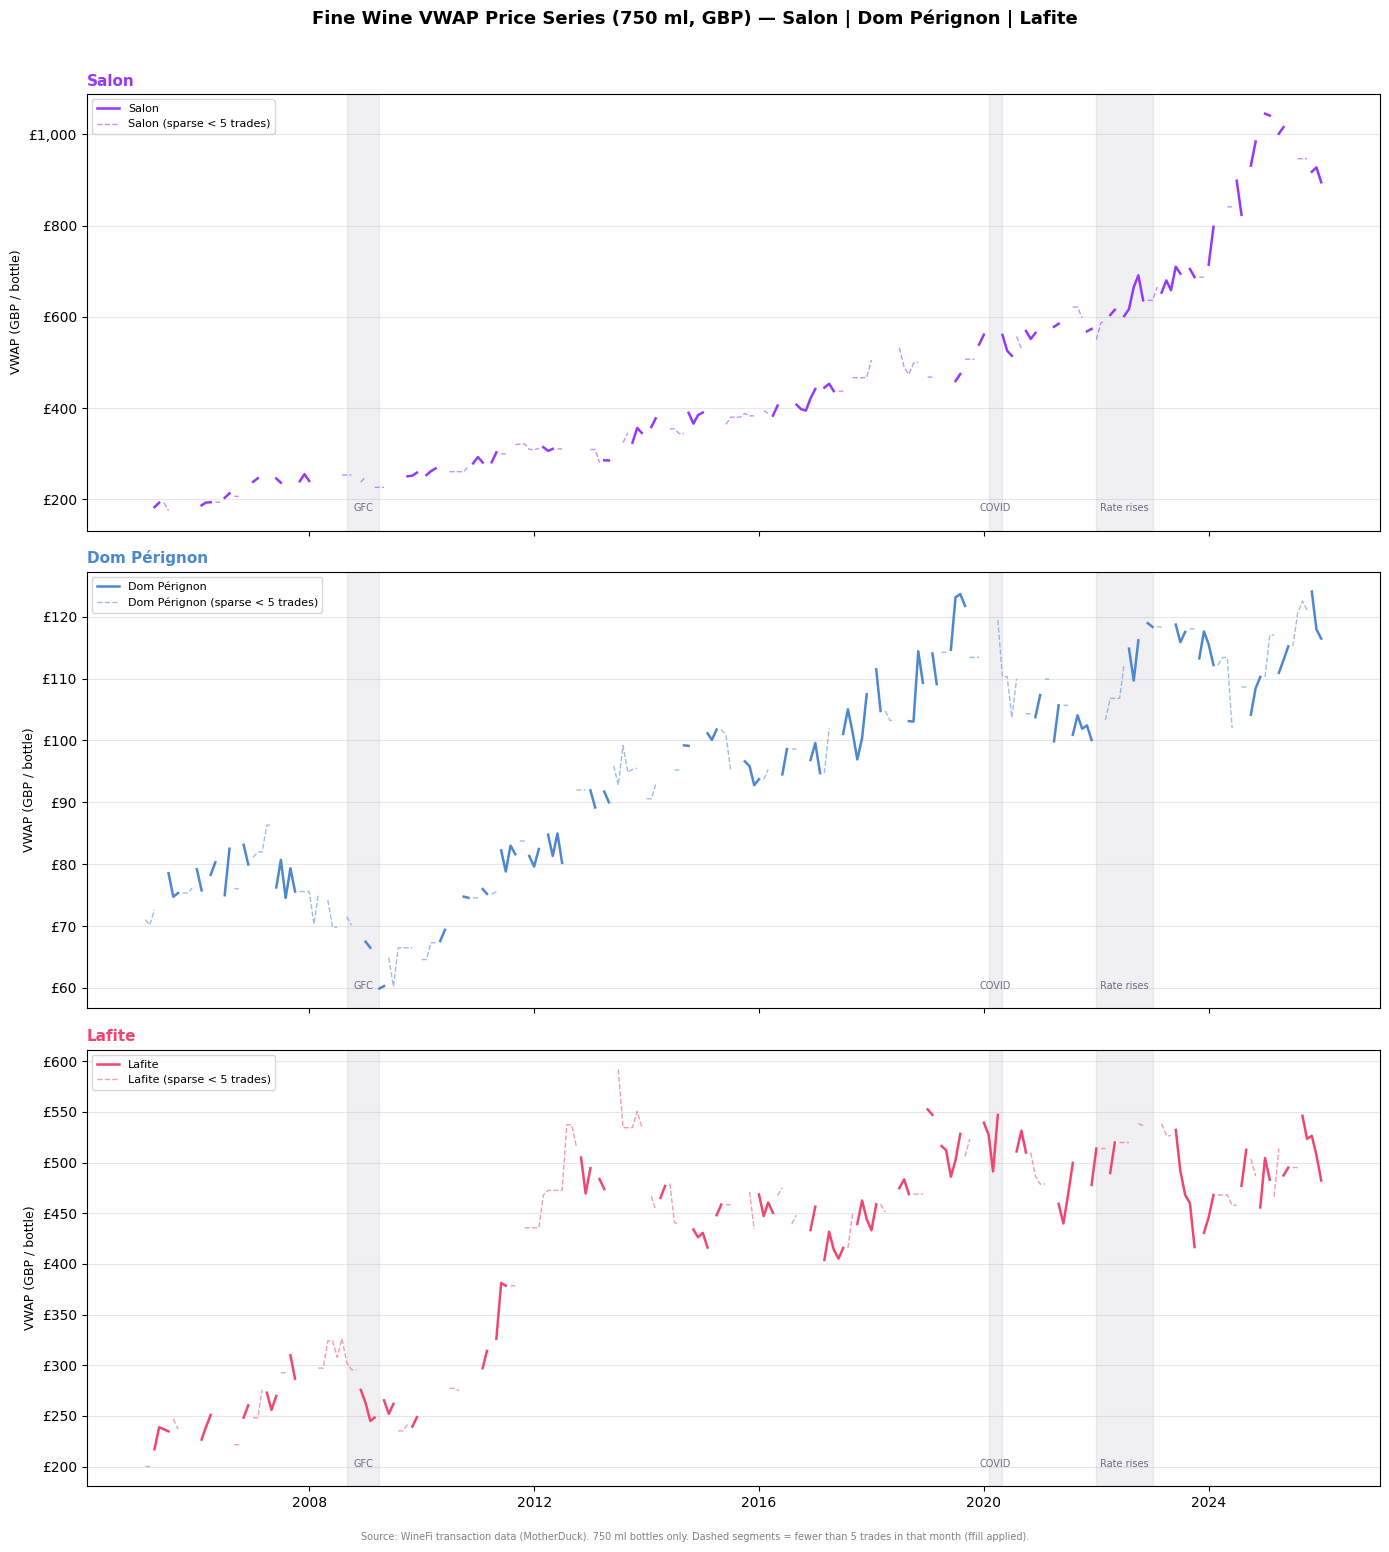

In [5]:
fig, axes = plt.subplots(
    len(wine_names_present), 1,
    figsize=(14, 5 * len(wine_names_present)),
    sharex=True,
)
if len(wine_names_present) == 1:
    axes = [axes]

fig.suptitle(
    "Fine Wine VWAP Price Series (750 ml, GBP) — Salon | Dom Pérignon | Lafite",
    fontsize=13, fontweight="bold", y=1.01,
)

for ax, wine_name in zip(axes, wine_names_present):
    color       = WINE_COLORS[wine_name]
    price_ffill = wine_price_ffill[wine_name]
    price_raw   = wine_price_raw[wine_name]
    trades_s    = wine_trades_wide[wine_name]
    sparse_mask = trades_s.fillna(0) < SPARSE_THRESHOLD

    # Shade stress periods
    for p_start, p_end, p_label in STRESS_PERIODS:
        ax.axvspan(pd.Timestamp(p_start), pd.Timestamp(p_end),
                   alpha=0.08, color=STRESS_SHADE, zorder=0)

    # Solid line: dense months; dashed line: sparse/ffilled months
    dense_s  = price_ffill.where(~sparse_mask)
    sparse_s = price_ffill.where(sparse_mask)

    ax.plot(dense_s.index,  dense_s.values,  color=color, linewidth=1.8, label=wine_name)
    ax.plot(sparse_s.index, sparse_s.values, color=color, linewidth=1.0,
            linestyle="--", alpha=0.55,
            label=f"{wine_name} (sparse < {SPARSE_THRESHOLD} trades)")

    ax.set_ylabel("VWAP (GBP / bottle)", fontsize=9)
    ax.set_title(wine_name, fontsize=11, loc="left", color=color, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"\u00a3{x:,.0f}"))
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(axis="y", alpha=0.3)

    # Stress period labels
    ylim    = ax.get_ylim()
    y_label = ylim[0] + (ylim[1] - ylim[0]) * 0.04
    for p_start, p_end, p_label in STRESS_PERIODS:
        ts = pd.Timestamp(p_start)
        te = pd.Timestamp(p_end)
        ax.text(
            ts + (te - ts) / 2, y_label, p_label,
            ha="center", va="bottom", fontsize=7,
            color=STRESS_SHADE, alpha=0.8,
        )

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.text(
    0.5, -0.01,
    "Source: WineFi transaction data (MotherDuck). 750 ml bottles only. "
    "Dashed segments = fewer than 5 trades in that month (ffill applied).",
    ha="center", fontsize=7, color="gray",
)
plt.tight_layout()

out_path = IMAGES_DIR / "wine_price_series.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {out_path}")
plt.show()

## 4. Chart 2: GFC Drawdown Comparison

All series indexed to 100 at January 2007. Shows divergence during the 2008 GFC.
Wines + Liv-ex 100 + S&P 500 (GBP-adjusted).

Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/heterogeneity/gfc_drawdown_comparison.png


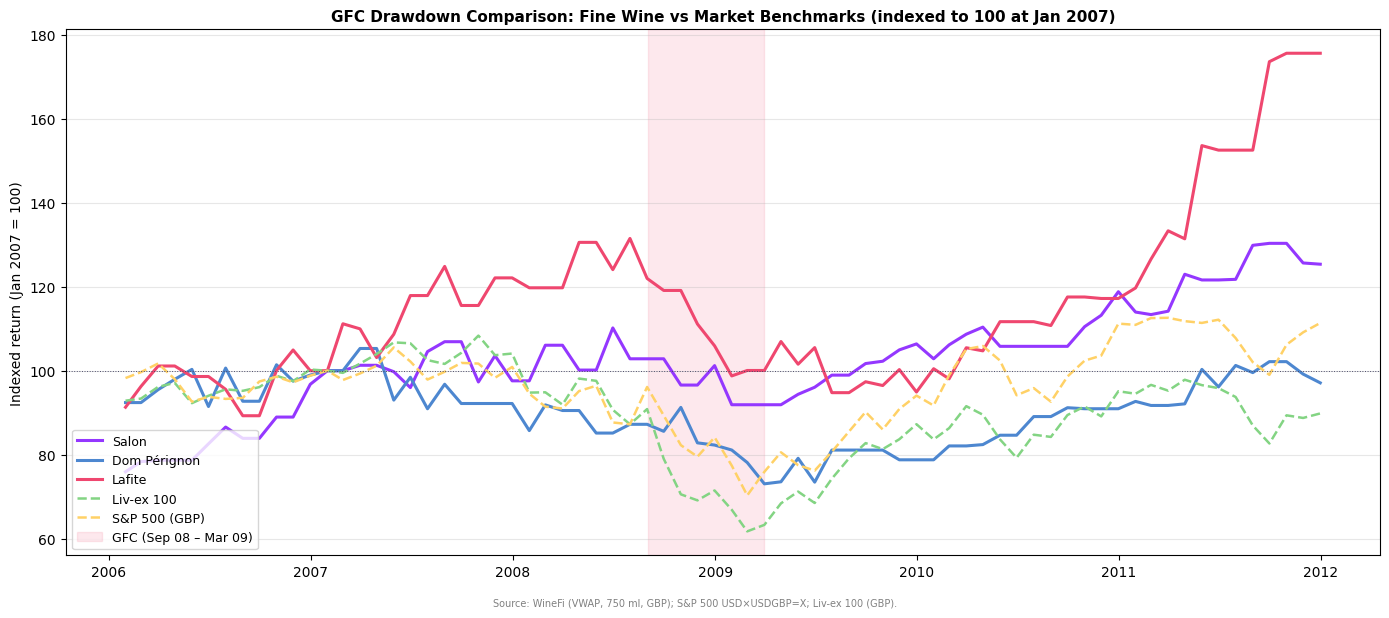

In [6]:
INDEX_BASE = pd.Timestamp("2007-01-01")
GFC_START  = pd.Timestamp("2008-09-01")
GFC_END    = pd.Timestamp("2009-03-31")
PLOT_START = pd.Timestamp("2006-01-01")
PLOT_END   = pd.Timestamp("2011-12-31")

# Build series dict: wines (ffill), Liv-ex 100, S&P 500 GBP
gfc_series = {}
for wine_name in wine_names_present:
    gfc_series[wine_name] = wine_price_ffill[wine_name].dropna()

if livex_col:
    gfc_series["Liv-ex 100"] = comp[livex_col].dropna()

gfc_series["S&P 500 (GBP)"] = sp500_gbp


def index_to_100(series, base_date):
    """Rebase series to 100 at base_date (nearest available month)."""
    candidates = series[(series.index >= base_date) &
                        (series.index <= base_date + pd.DateOffset(months=2))].dropna()
    if candidates.empty:
        return None
    base_val = candidates.iloc[0]
    if base_val == 0 or np.isnan(base_val):
        return None
    return series / base_val * 100


fig, ax = plt.subplots(figsize=(14, 6))

for name, series in gfc_series.items():
    s = series[(series.index >= PLOT_START) & (series.index <= PLOT_END)].dropna()
    if len(s) < 3:
        print(f"  Skipping '{name}': only {len(s)} points in window")
        continue

    s_indexed = index_to_100(s, INDEX_BASE)
    if s_indexed is None:
        print(f"  Skipping '{name}': cannot rebase at {INDEX_BASE.date()}")
        continue

    if name in WINE_COLORS:
        color, lw, ls = WINE_COLORS[name], 2.2, "-"
    elif "Liv-ex" in name:
        color, lw, ls = LIVEX_COLOR, 1.8, "--"
    else:
        color, lw, ls = SP500_COLOR, 1.8, "--"

    ax.plot(s_indexed.index, s_indexed.values, color=color,
            linewidth=lw, linestyle=ls, label=name)

# GFC shading
ax.axvspan(GFC_START, GFC_END, alpha=0.12, color="#EF476F", zorder=0, label="GFC (Sep 08 – Mar 09)")
ax.axhline(100, color=STRESS_SHADE, linewidth=0.7, linestyle=":")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Indexed return (Jan 2007 = 100)", fontsize=10)
ax.set_title(
    "GFC Drawdown Comparison: Fine Wine vs Market Benchmarks (indexed to 100 at Jan 2007)",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9, loc="lower left")
ax.grid(axis="y", alpha=0.3)
fig.text(
    0.5, -0.02,
    "Source: WineFi (VWAP, 750 ml, GBP); S&P 500 USD×USDGBP=X; Liv-ex 100 (GBP).",
    ha="center", fontsize=7, color="gray",
)
plt.tight_layout()

out_path = IMAGES_DIR / "gfc_drawdown_comparison.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {out_path}")
plt.show()

## 5. Chart 3: Monthly Trade Volume Per Wine

Raw trade counts (no ffill). Three series on one chart. Stress periods shaded.

Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/heterogeneity/wine_trade_volume.png


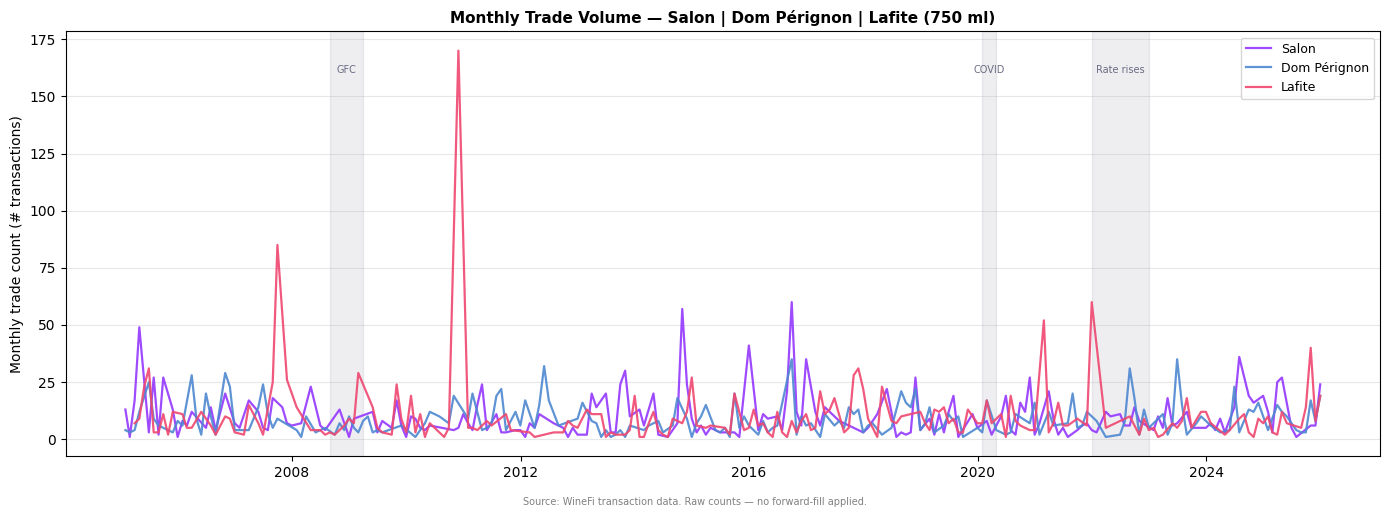

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

for wine_name in wine_names_present:
    color    = WINE_COLORS[wine_name]
    trades_s = wine_trades_wide[wine_name].dropna()
    ax.plot(
        trades_s.index, trades_s.values,
        color=color, linewidth=1.6, label=wine_name, alpha=0.9,
    )

# Shade stress periods
for p_start, p_end, p_label in STRESS_PERIODS:
    ts = pd.Timestamp(p_start)
    te = pd.Timestamp(p_end)
    ax.axvspan(ts, te, alpha=0.09, color=STRESS_SHADE, zorder=0)
    ylim    = ax.get_ylim()
    y_label = ylim[0] + (ylim[1] - ylim[0]) * 0.92
    ax.text(
        ts + (te - ts) / 2, y_label, p_label,
        ha="center", va="top", fontsize=7,
        color=STRESS_SHADE, alpha=0.8,
    )

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Monthly trade count (# transactions)", fontsize=10)
ax.set_title(
    "Monthly Trade Volume — Salon | Dom Pérignon | Lafite (750 ml)",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.text(
    0.5, -0.02,
    "Source: WineFi transaction data. Raw counts — no forward-fill applied.",
    ha="center", fontsize=7, color="gray",
)
plt.tight_layout()

out_path = IMAGES_DIR / "wine_trade_volume.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {out_path}")
plt.show()

## 6. Chart 4: Stress Period Performance — Grouped Bar

Total return (%) for each of 3 stress windows: GFC, COVID, Rate rises.
Assets: Salon, Dom Pérignon, Lafite, Liv-ex 100, S&P 500 (GBP).

In [8]:
# Build asset series dict for stress calculations
stress_assets = {}
for wine_name in wine_names_present:
    stress_assets[wine_name] = wine_price_ffill[wine_name].dropna()

if livex_col:
    stress_assets["Liv-ex 100"] = comp[livex_col].dropna()

stress_assets["S&P 500 (GBP)"] = sp500_gbp


def period_return(series, start, end):
    """Return total % return of series between start and end (inclusive)."""
    window = series[(series.index >= pd.Timestamp(start)) &
                    (series.index <= pd.Timestamp(end))].dropna()
    if len(window) < 2:
        return np.nan
    return float((window.iloc[-1] - window.iloc[0]) / window.iloc[0] * 100)


stress_rows = []
for p_start, p_end, p_label in STRESS_PERIODS:
    row = {"Period": p_label}
    for name, series in stress_assets.items():
        row[name] = period_return(series, p_start, p_end)
    stress_rows.append(row)

stress_df = pd.DataFrame(stress_rows).set_index("Period")

print("Return (%) during each stress period:")
display(stress_df.round(1))

Return (%) during each stress period:


,Salon,Dom Pérignon,Lafite,Liv-ex 100,S&P 500 (GBP)
Period,,,,,
GFC,-10.6,-14.6,-16.0,-19.9,-15.0
COVID,0.0,-7.7,11.4,-10.3,1.9
Rate rises,8.2,14.6,1.3,-0.2,-5.5


Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/heterogeneity/stress_period_performance.png


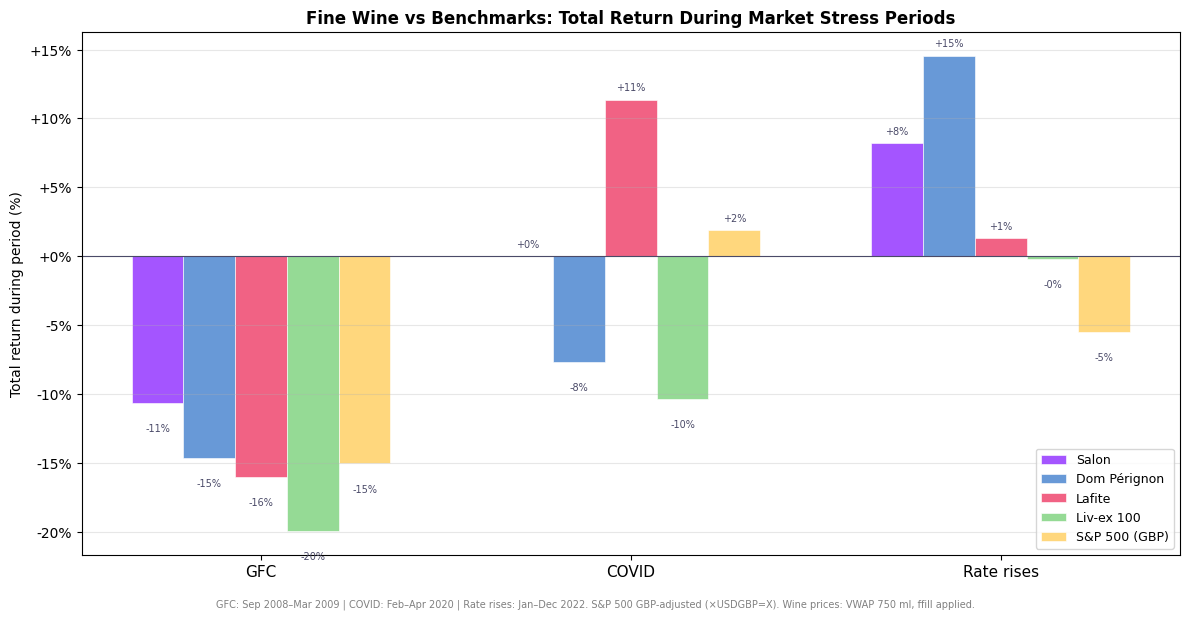

In [9]:
all_cols = list(stress_df.columns)
n_assets  = len(all_cols)
n_periods = len(stress_df)
x         = np.arange(n_periods)
width     = 0.7 / n_assets

color_list = []
for c in all_cols:
    if c in WINE_COLORS:
        color_list.append(WINE_COLORS[c])
    elif "Liv-ex" in c:
        color_list.append(LIVEX_COLOR)
    else:
        color_list.append(SP500_COLOR)

fig, ax = plt.subplots(figsize=(12, 6))

for i, (col, col_color) in enumerate(zip(all_cols, color_list)):
    vals   = stress_df[col].values.astype(float)
    offset = (i - n_assets / 2 + 0.5) * width
    bars   = ax.bar(
        x + offset, vals, width=width,
        color=col_color, label=col,
        alpha=0.85, edgecolor="white", linewidth=0.5,
    )
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + (0.5 if val >= 0 else -1.5),
                f"{val:+.0f}%",
                ha="center",
                va="bottom" if val >= 0 else "top",
                fontsize=7, color=STRESS_SHADE,
            )

ax.axhline(0, color=STRESS_SHADE, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(stress_df.index, fontsize=11)
ax.set_ylabel("Total return during period (%)", fontsize=10)
ax.set_title(
    "Fine Wine vs Benchmarks: Total Return During Market Stress Periods",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
fig.text(
    0.5, -0.02,
    "GFC: Sep 2008–Mar 2009 | COVID: Feb–Apr 2020 | Rate rises: Jan–Dec 2022. "
    "S&P 500 GBP-adjusted (×USDGBP=X). Wine prices: VWAP 750 ml, ffill applied.",
    ha="center", fontsize=7, color="gray",
)
plt.tight_layout()

out_path = IMAGES_DIR / "stress_period_performance.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {out_path}")
plt.show()

## 7. Data Quality Assertions

All assertions must pass before the notebook is considered complete.

In [10]:
errors = []

# 1. Required PNG files saved
required_images = [
    "wine_price_series.png",
    "gfc_drawdown_comparison.png",
    "wine_trade_volume.png",
    "stress_period_performance.png",
]
for img in required_images:
    path = IMAGES_DIR / img
    if not path.exists():
        errors.append(f"Missing image: {img}")
    elif path.stat().st_size < 5_000:
        errors.append(f"Image appears empty (<5 KB): {img}")

# 2. All three wines present in price series
for wine in ["Salon", "Dom Pérignon", "Lafite"]:
    if wine not in wine_names_present:
        errors.append(f"Wine '{wine}' missing from focal wines parquet")

# 3. Price series has data from at least 2005 to 2020
if not wine_price_ffill.empty:
    if wine_price_ffill.index.min().year > 2005:
        errors.append(
            f"Price series starts {wine_price_ffill.index.min().year}, expected <= 2005"
        )
    if wine_price_ffill.index.max().year < 2020:
        errors.append(
            f"Price series ends {wine_price_ffill.index.max().year}, expected >= 2020"
        )
else:
    errors.append("wine_price_ffill is empty")

# 4. S&P 500 GBP series has data
if len(sp500_gbp) < 100:
    errors.append(f"sp500_gbp has only {len(sp500_gbp)} rows (expected >= 100)")

# 5. Stress period returns computed for at least 2 assets in each period
for period in stress_df.index:
    valid = stress_df.loc[period].notna().sum()
    if valid < 2:
        errors.append(
            f"Stress period '{period}': only {valid} assets have return data (expected >= 2)"
        )

# Report
if errors:
    for err in errors:
        print(f"FAIL: {err}")
    raise AssertionError("Data quality assertions failed — see output above")
else:
    print("All data quality assertions PASSED.")
    print(f"  Images saved ({len(required_images)}): {required_images}")
    print(f"  Wines present: {wine_names_present}")
    print(f"  Price series: {wine_price_ffill.index.min().date()} → {wine_price_ffill.index.max().date()}")
    print(f"  S&P 500 GBP: {len(sp500_gbp)} months")
    print()
    print("Stress period returns (%):\n", stress_df.round(1).to_string())

All data quality assertions PASSED.
  Images saved (4): ['wine_price_series.png', 'gfc_drawdown_comparison.png', 'wine_trade_volume.png', 'stress_period_performance.png']
  Wines present: ['Salon', 'Dom Pérignon', 'Lafite']
  Price series: 2005-01-31 → 2025-12-31
  S&P 500 GBP: 268 months

Stress period returns (%):
             Salon  Dom Pérignon  Lafite  Liv-ex 100  S&P 500 (GBP)
Period                                                            
GFC         -10.6         -14.6   -16.0       -19.9          -15.0
COVID         0.0          -7.7    11.4       -10.3            1.9
Rate rises    8.2          14.6     1.3        -0.2           -5.5


## Summary

| Output | Description | Location |
|--------|-------------|----------|
| `wine_price_series.png` | VWAP price series per wine (2005+), stress periods shaded | `images/heterogeneity/` |
| `gfc_drawdown_comparison.png` | All series indexed to 100 at Jan 2007 across GFC window | `images/heterogeneity/` |
| `wine_trade_volume.png` | Raw monthly trade counts (3 wine series), stress shaded | `images/heterogeneity/` |
| `stress_period_performance.png` | Grouped bar: total return % per asset per stress period | `images/heterogeneity/` |

**All prices are in GBP.** S&P 500 GBP-adjusted via `USDGBP=X`.  
Data loaded from `focal_wines_vwap_monthly.parquet` produced by `01_data_setup.ipynb`.